# Breast Cancer Ultrasound Classification Using Machine Learning
## Auditable evaluation and research dashboard

This notebook is a compact, executable view of the repository evidence. It does not contain hand-entered benchmark values. The validated run uses repaired subject-level BrEaST and OASBUD splits. The local BUSI derivative is excluded because its files were renamed and its patient mapping and transformation history cannot be reconstructed. That prevents a reproducible check for patient separation, duplicate cases, label conflicts, overlays, and other published curation decisions. The exclusion applies to the local derivative, not to the original published BUSI dataset. Metrics are local cohort research evidence, not clinical performance estimates.

## 1. Environment and project location

Run the notebook from the repository root after installing `requirements.txt`. The cell records basic runtime information without modifying the environment.

In [1]:
from pathlib import Path
import json, platform, subprocess, sys

ROOT = Path.cwd()
assert (ROOT / "src").is_dir(), "Open this notebook from the dissertation repository root."
print({"python": sys.version.split()[0], "platform": platform.platform(), "project": ROOT.name})

{'python': '3.9.6', 'platform': 'macOS-15.7.7-x86_64-i386-64bit', 'project': 'Dissertation'}


## 2. Audit data integrity

The audit derives subject identifiers where the local filename convention permits and records cross-partition subjects. The validated run audits BrEaST and OASBUD. BUSI is documented as an excluded local derivative because its original identifiers are unavailable.

In [2]:
subprocess.run(
    [sys.executable, "scripts/audit_data.py", "--datasets", "breast", "oasbud", "--output", "outputs/data_audit.json"],
    check=True,
)
audit = json.loads((ROOT / "outputs/data_audit.json").read_text())
audit["audit_passed"], audit["failed_datasets"]

{
  "audit_passed": true,
  "audited_datasets": [
    "breast",
    "oasbud"
  ],
  "breast": {
    "counts": {
      "test": {
        "benign": 19,
        "malignant": 13
      },
      "train": {
        "benign": 101,
        "malignant": 60,
        "normal": 3
      },
      "val": {
        "benign": 19,
        "malignant": 13,
        "normal": 1
      }
    },
    "cross_split_subjects": {},
    "subject_ids_verifiable": true
  },
  "failed_datasets": [],
  "notes": [
    "BUSI filenames were renamed during curation, so patient-level separation cannot be verified from this copy.",
    "A non-empty cross_split_subjects section invalidates a patient-independent estimate until the cohort is rebuilt.",
    "A dataset omitted from an experiment must not be described as part of that experiment's evidence."
  ],
  "oasbud": {
    "counts": {
      "test": {
        "benign": 14,
        "malignant": 16
      },
      "train": {
        "benign": 66,
        "malignant": 72
      },

(True, [])

In [3]:
import pandas as pd

rows = []
for dataset in audit["audited_datasets"]:
    for split, labels in audit[dataset]["counts"].items():
        rows.append({"dataset": dataset, "split": split, "images": sum(labels.values())})
pd.DataFrame(rows).pivot(index="dataset", columns="split", values="images").fillna(0).astype(int)

split,test,train,val
dataset,,,
breast,32,164,33
oasbud,30,138,30


## 3. Generate checkpoint evidence

`evaluate.py` uses the shared preprocessing implementation and writes per-image predictions before its aggregate summary. This cell can take several minutes on CPU.

In [4]:
RUN_EVALUATION = False  # Set True to regenerate metrics and plots from the bundled checkpoint.
if RUN_EVALUATION:
    subprocess.run([sys.executable, "evaluate.py", "--split", "test"], check=True)
else:
    print("Using the committed local evidence files; set RUN_EVALUATION=True to regenerate them.")

Using the committed local evidence files; set RUN_EVALUATION=True to regenerate them.


## 4. Inspect generated metrics and uncertainty

The primary values come from `outputs/metrics.json`. Additional threshold and calibration diagnostics come from the preserved per-image probabilities in `outputs/predictions.csv` and are stored in `outputs/extended_evaluation.json`. The audit status is shown alongside them so the evidence boundary remains attached to the headline numbers.

In [5]:
metrics = json.loads((ROOT / "outputs/metrics.json").read_text())
summary = pd.DataFrame([metrics["summary"]], index=[metrics["model_name"]])
display(summary.style.format("{:.4f}"))
print({
    "samples": metrics["samples"],
    "split": metrics["split"],
    "evidence_status": metrics.get("evidence_status", "legacy provisional record"),
    "data_audit_passed": metrics.get("data_audit_passed", False),
})

TypeError: unsupported format string passed to dict.__format__

{'samples': 62, 'split': 'test', 'evidence_status': 'validated', 'data_audit_passed': True}


In [6]:
extended = json.loads((ROOT / "outputs/extended_evaluation.json").read_text())
benchmark = json.loads((ROOT / "outputs/model_benchmark.json").read_text())

overall = extended["overall"]
pd.Series({
    "malignant precision": overall["malignant_precision"],
    "malignant recall": overall["malignant_recall"],
    "specificity": overall["specificity"],
    "ROC-AUC": overall["roc_auc"],
    "average precision": overall["average_precision"],
    "Brier score": overall["brier_score"],
    "expected calibration error": overall["expected_calibration_error"],
}).to_frame("EfficientNet-B0").style.format("{:.4f}")

,EfficientNet-B0
malignant precision,0.6364
malignant recall,0.7241
specificity,0.6364
ROC-AUC,0.7419
average precision,0.6803
Brier score,0.2144
expected calibration error,0.0652


In [7]:
comparison_rows = []
for record in benchmark["records"]:
    result = record["summary"]
    comparison_rows.append({
        "model": record["model_name"],
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "roc_auc": result["roc_auc"],
        "accuracy_95_ci": tuple(result["bootstrap_95_ci"]["accuracy"]),
        "roc_auc_95_ci": tuple(result["bootstrap_95_ci"]["roc_auc"]),
    })
pd.DataFrame(comparison_rows).set_index("model")

,accuracy,macro_f1,roc_auc,accuracy_95_ci,roc_auc_95_ci
model,,,,,
efficientnet_b0,0.6774,0.6774,0.7419,"(0.5645, 0.7903)","(0.6217, 0.8616)"
resnet50,0.5645,0.5374,0.6364,"(0.4355, 0.6935)","(0.5054, 0.7701)"
custom_cnn,0.6452,0.6452,0.6708,"(0.5323, 0.7581)","(0.533, 0.7979)"


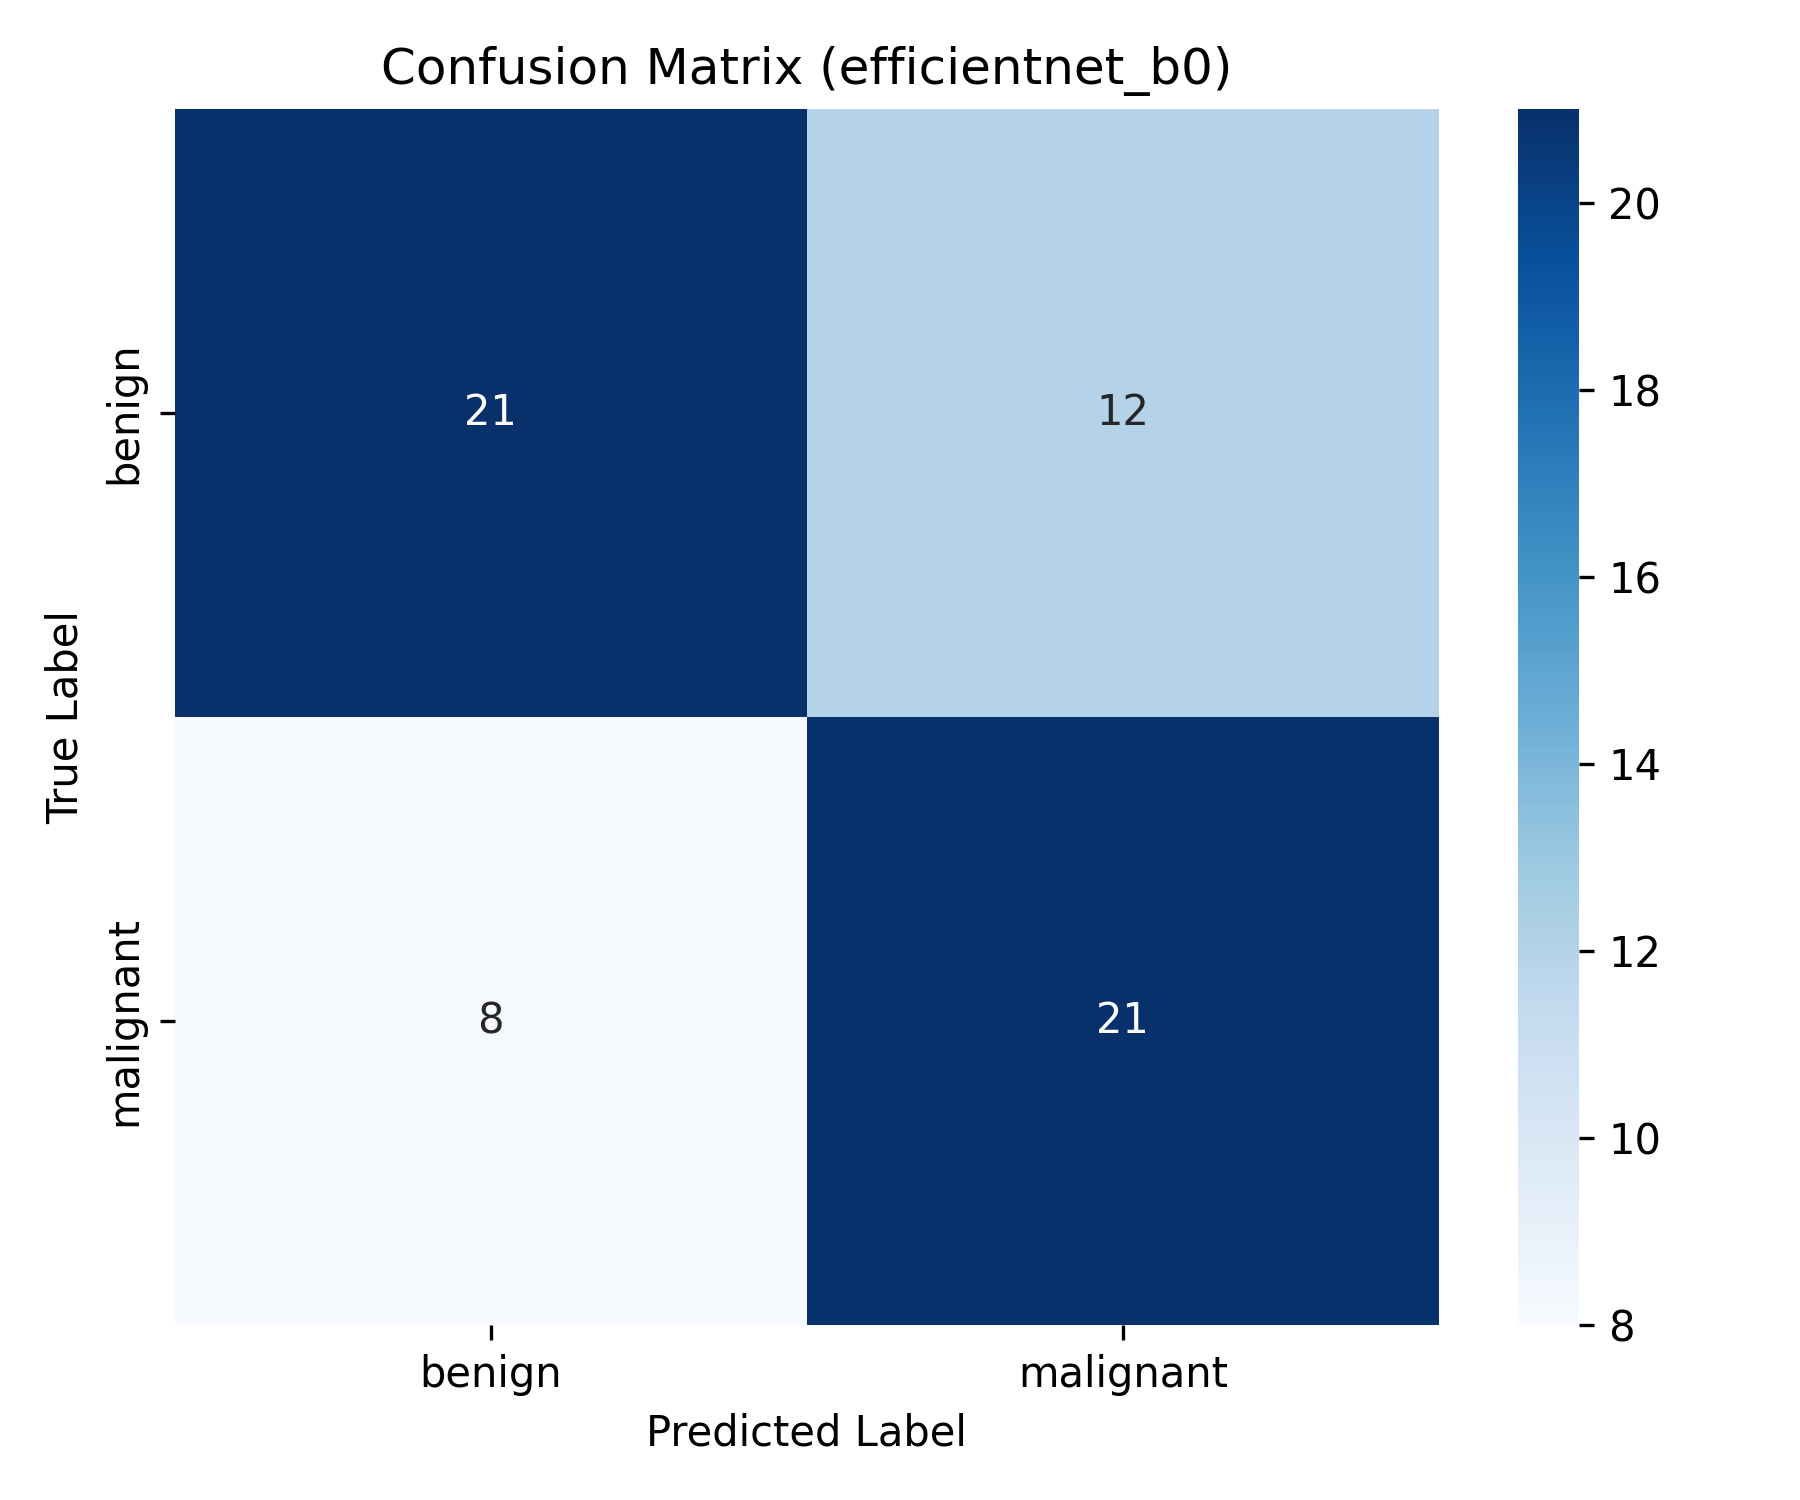

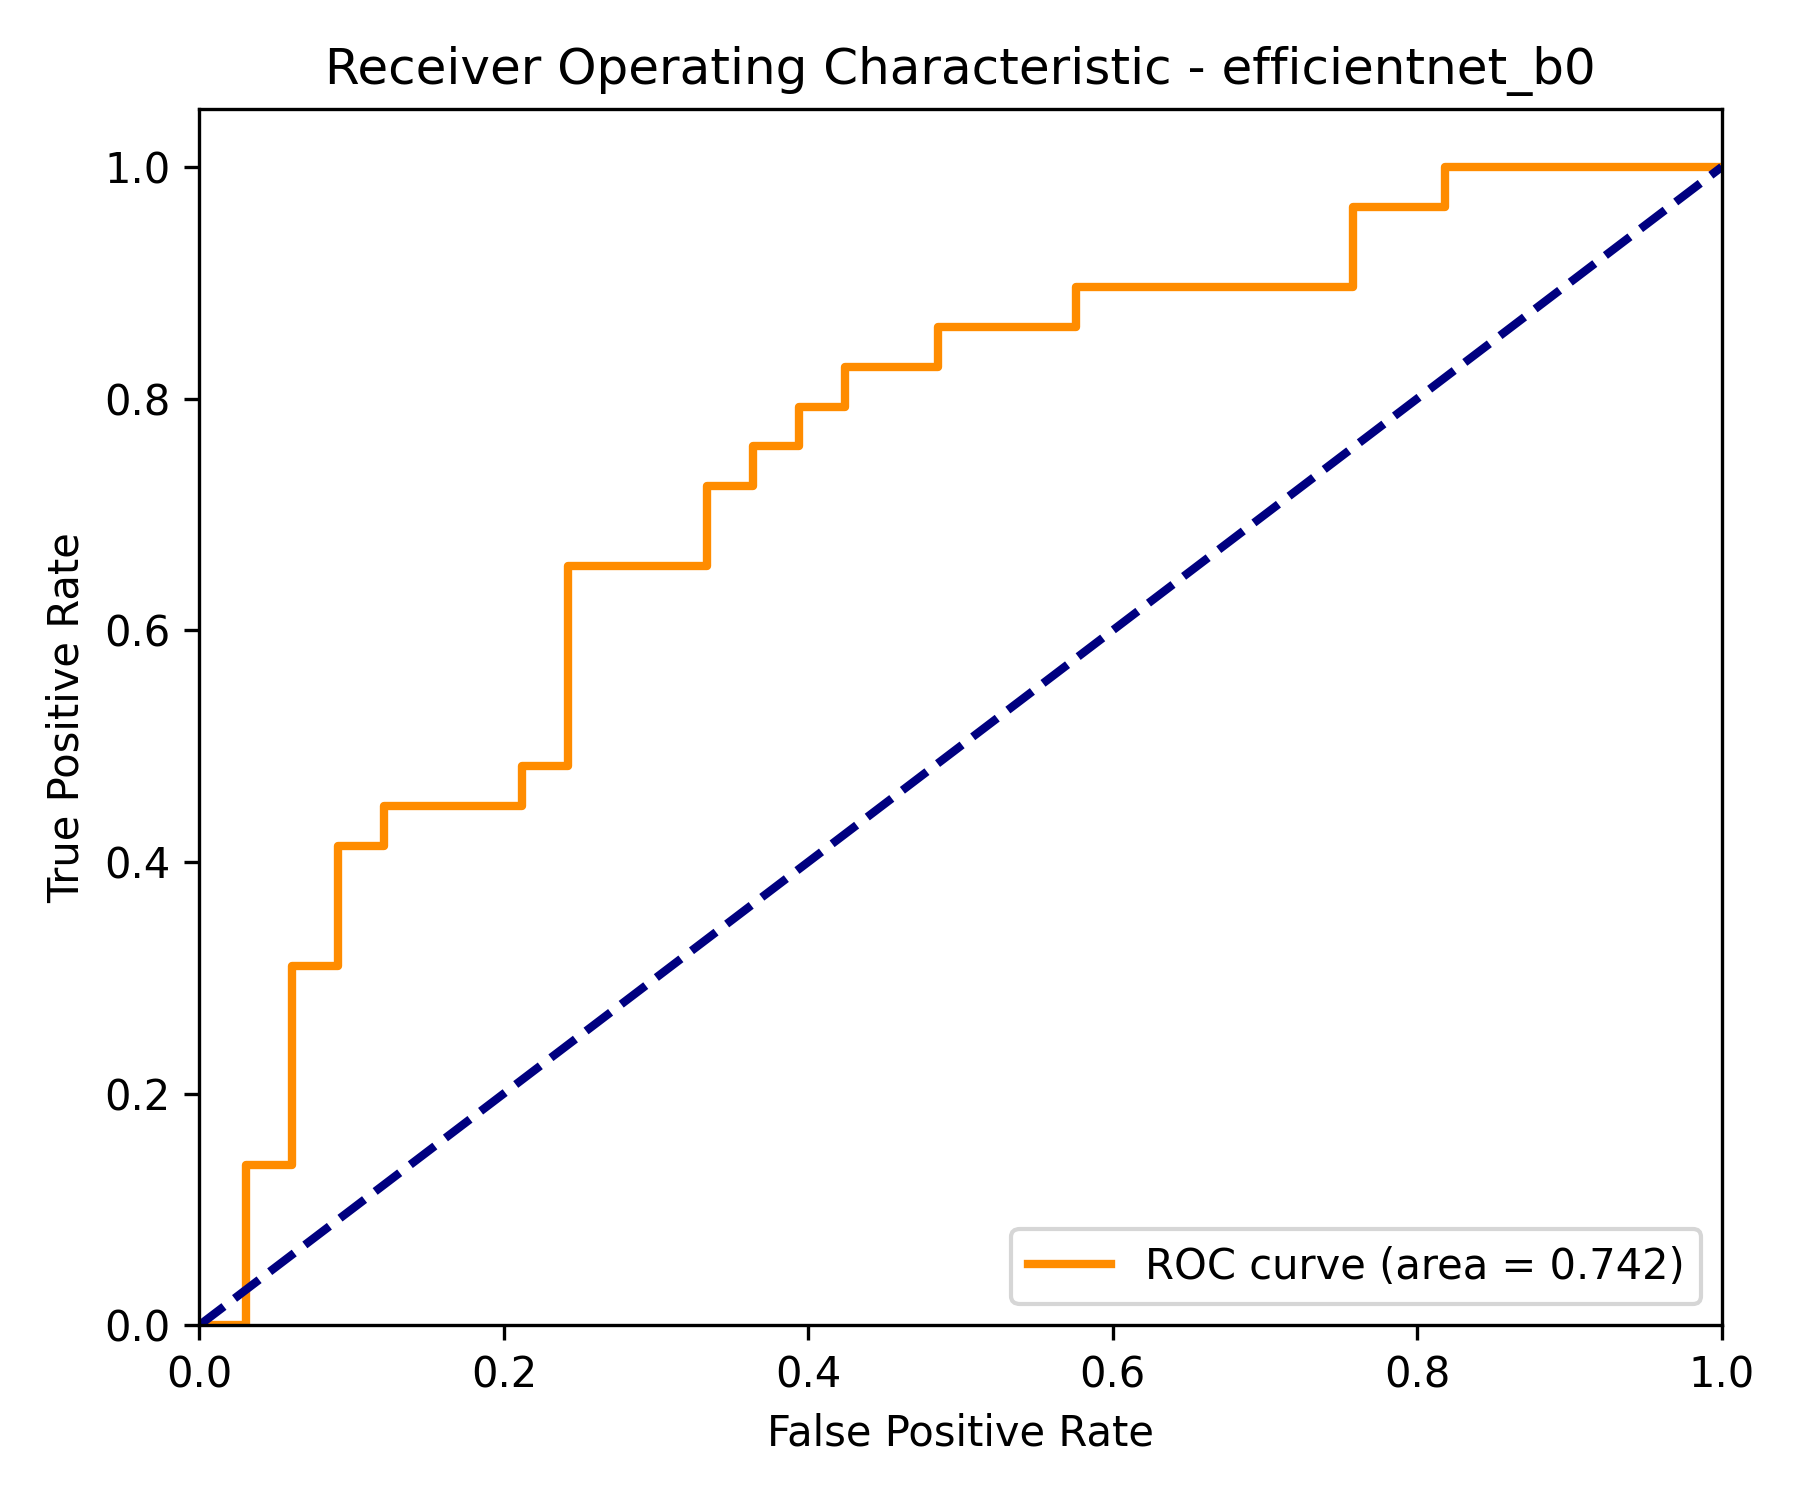

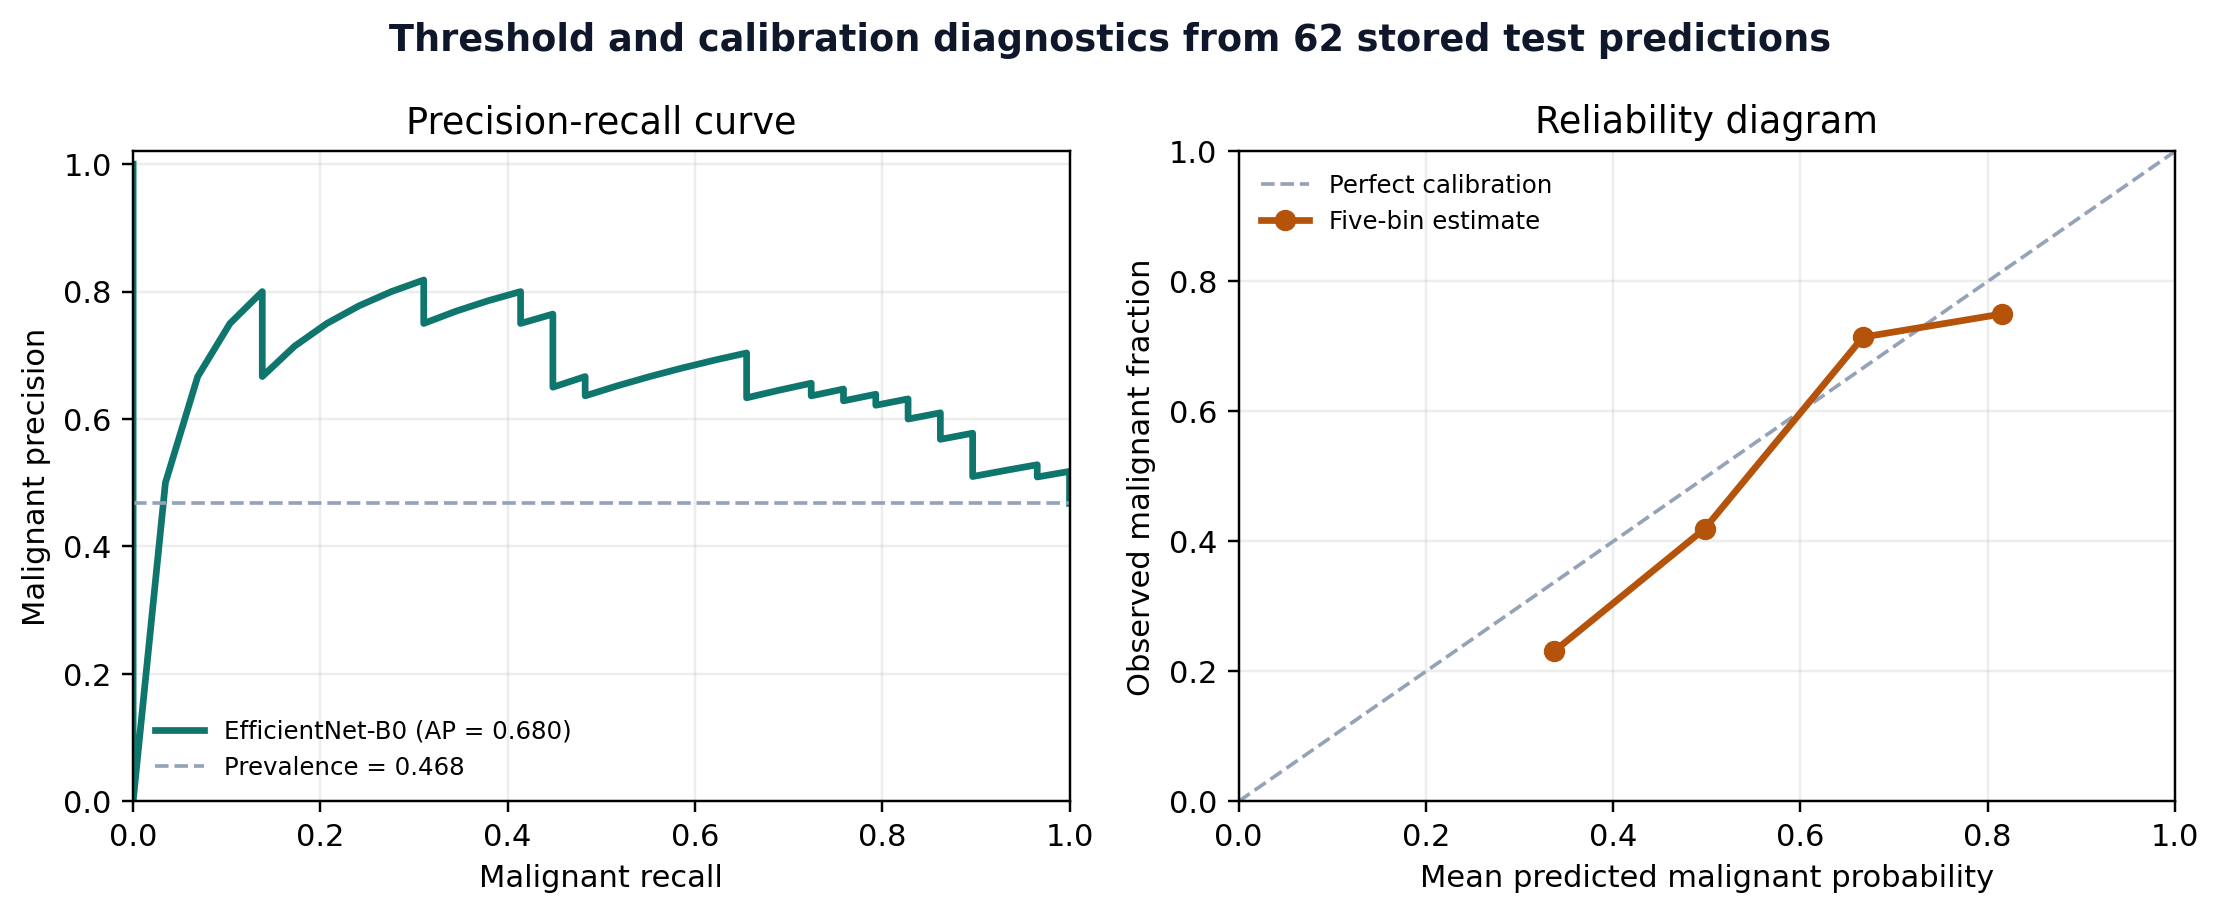

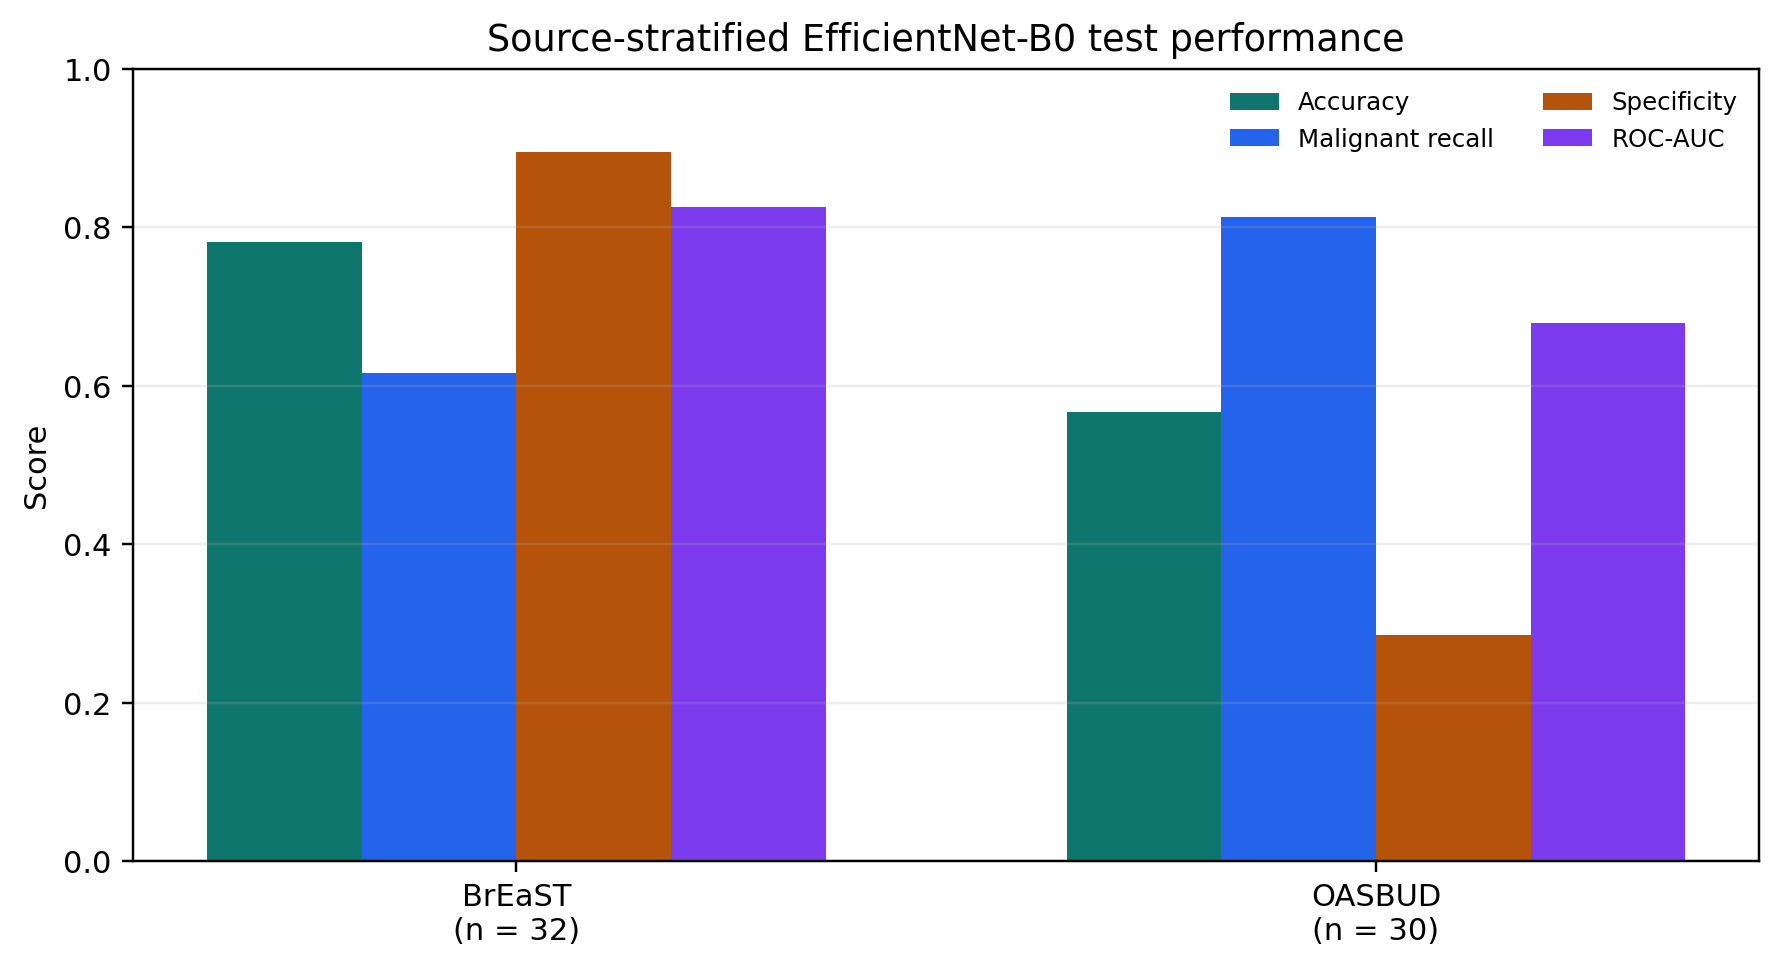

In [8]:
from IPython.display import Image, display

display(Image(filename="outputs/confusion_matrix.png", width=520))
display(Image(filename="outputs/roc_curve.png", width=520))
display(Image(filename="outputs/discrimination_calibration.png", width=900))
display(Image(filename="outputs/source_stratified_performance.png", width=760))

## 5. Source-specific error analysis

The fixed 0.5 threshold produces eight false negatives and twelve false positives overall. BrEaST contributes two false positives and five false negatives. OASBUD contributes ten false positives and three false negatives. The subsets differ in source, acquisition, reconstruction, case mix, and sample size, so this descriptive analysis cannot identify a cause or rank dataset quality.

In [9]:
source_rows = []
for source, result in extended["by_source"].items():
    tn, fp = result["confusion_matrix"][0]
    fn, tp = result["confusion_matrix"][1]
    source_rows.append({
        "source": source,
        "n": result["samples"],
        "accuracy": result["accuracy"],
        "malignant_precision": result["malignant_precision"],
        "malignant_recall": result["malignant_recall"],
        "specificity": result["specificity"],
        "roc_auc": result["roc_auc"],
        "false_positives": fp,
        "false_negatives": fn,
    })
pd.DataFrame(source_rows).set_index("source").style.format({
    "accuracy": "{:.4f}",
    "malignant_precision": "{:.4f}",
    "malignant_recall": "{:.4f}",
    "specificity": "{:.4f}",
    "roc_auc": "{:.4f}",
})

,n,accuracy,malignant_precision,malignant_recall,specificity,roc_auc,false_positives,false_negatives
source,,,,,,,,
BrEaST,32,0.7812,0.8000,0.6154,0.8947,0.8259,2,5
OASBUD,30,0.5667,0.5652,0.8125,0.2857,0.6786,10,3


## 6. Interpretation

The current run confirms that the checkpoint, data loader, preprocessing, evaluator, and artifact writers operate together on a patient-separated local cohort. It does **not** establish external or clinical generalisation. The local BUSI derivative remains intentionally excluded from every validated result.

EfficientNet-B0 has the strongest point estimates in the internal comparison, but all three bootstrap intervals overlap. The preserved benchmark contains per-model summaries rather than paired predictions, so a paired significance test cannot be reconstructed. The custom CNN exceeds ResNet-50 in this run, but that result does not establish a breakthrough or population-level superiority.

The existing checkpoints retain only their selected validation points, not complete epoch histories. The report therefore gives those points and does not invent learning curves. Future training runs now save an epoch-by-epoch JSON record. Multi-seed training, expert review of errors, and external validation remain future work and were not performed for this revision.

## Submission checklist

- [x] Dataset versions, exclusions, and label mapping recorded
- [x] Audited subjects remain within one partition for BrEaST and OASBUD
- [x] BUSI derivative excluded from validated training and evaluation
- [x] Seeds, configuration, and checkpoint hashes recorded where available
- [x] Per-image EfficientNet-B0 test predictions retained
- [x] Uncertainty, calibration, error cases, and source limitations reported
- [x] LaTeX, slides, README, notebook, and website aligned with the same evidence
- [ ] Ethics reference confirmed by the student before submission